In [122]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

from sklearn.metrics import roc_curve, precision_recall_curve

In [2]:
df = pd.read_csv("creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [4]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
# Statistical summary of the dataset

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.661136e-05,1.958679,-56.407510,-0.920327,0.018027,1.315632,2.454930
V2,284807.0,8.124322e-06,1.651295,-72.715728,-0.598532,0.065467,0.803724,22.057729
V3,284807.0,1.497029e-02,8.073856,-48.325589,-0.890365,0.179832,1.027212,4232.000000
V4,284807.0,2.323995e-05,1.415859,-5.683171,-0.848611,-0.019816,0.743355,16.875344
V5,284807.0,2.234059e-05,1.380234,-113.743307,-0.691568,-0.054314,0.611926,34.801666
V6,284807.0,-1.603908e-05,1.332244,-26.160506,-0.768290,-0.274159,0.398487,73.301626
V7,284807.0,2.910118e-05,1.237076,-43.557242,-0.554011,0.040104,0.570450,120.589494
V8,284807.0,2.764611e-06,1.194354,-73.216718,-0.208630,0.022358,0.327349,20.007208
V9,284807.0,4.310673e-03,2.538010,-13.434066,-0.643068,-0.051331,0.597139,1221.000000


In [6]:
# Check target variable distribution

print("class distribution:")
print(df['Class'].value_counts())

print("\nclass distribution in percentage:")
print(df['Class'].value_counts(normalize=True) * 100)

class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

class distribution in percentage:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [7]:
# check missing values

df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [8]:
# duplicate transactions

df.duplicated().sum()


np.int64(1081)

In [9]:
# Display the dupliacate rows

duplicates = df[df.duplicated(keep=False)]

print("Total duplicate rows:", len(duplicates))

duplicates.head(10)



Total duplicate rows: 1854


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
113,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
114,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
115,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0
220,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0
221,145.0,-2.420413,1.947885,0.553646,0.983069,-0.281518,2.408958,-1.401613,-0.188299,0.675878,...,1.213826,-1.238620,0.006927,-1.724222,0.239603,-0.313703,-0.188281,0.119831,6.00,0


In [10]:
# Check whether dupliactes include the fraud

# Class distribution in the duplicate rows

duplicates["Class"].value_counts()

Class
0    1822
1      32
Name: count, dtype: int64

In [11]:
# Percentage of fraud and legitimate transactions in the duplicate rows

duplicates["Class"].value_counts(normalize=True) * 100

Class
0    98.274002
1     1.725998
Name: proportion, dtype: float64

In [12]:
# Check exact duplicates counts by class

df[df.duplicated(keep=False)].groupby('Class').size()

Class
0    1822
1      32
dtype: int64

In [13]:
# Remove exact duplicate rows

df = df.drop_duplicates()

In [14]:
df.shape

(283726, 31)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
# check class distribution after removing duplicates

print("class distribution:")
print(df["Class"].value_counts())

print("\nclass distribution in percentage:")
print(df["Class"].value_counts(normalize=True) * 100)

class distribution:
Class
0    283253
1       473
Name: count, dtype: int64

class distribution in percentage:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [17]:
# Check missing values after removing duplicates

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values[missing_values > 0])


Missing values in each column:
Series([], dtype: int64)


In [18]:
print("Total missing values:", df.isnull().sum().sum())


Total missing values: 0


In [19]:
# Check data types

df.dtypes

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

In [20]:
df.dtypes.value_counts()

float64    30
int64       1
Name: count, dtype: int64

In [21]:
# Time variable summary

print("Time Statistics:")
print(df["Time"].describe())

Time Statistics:
count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64


In [22]:
# Check maximum and minimum Time

print("Maximum Time:", df["Time"].max())
print("Minimum Time:", df["Time"].min())

Maximum Time: 172792.0
Minimum Time: 0.0


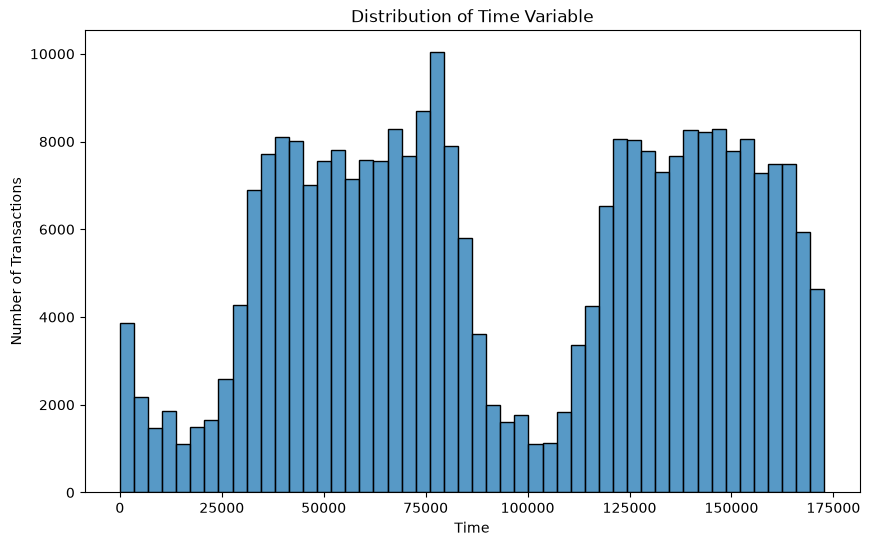

In [23]:
# Visualize the distribution of the Time variable

plt.figure(figsize=(10, 6))

sns.histplot(data=df, x="Time", bins=50)

plt.title("Distribution of Time Variable")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.show()

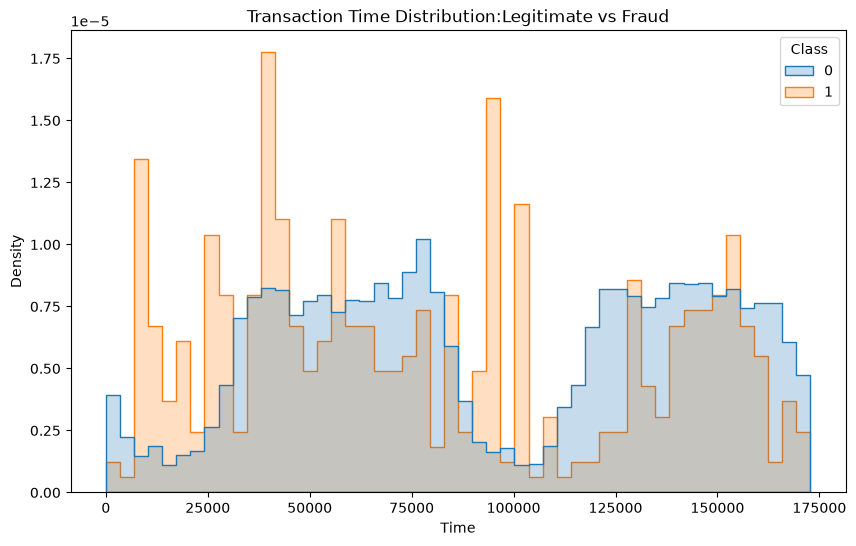

In [24]:
# Time by transaction class

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=50,
    element="step",
    stat="density",
    common_norm=False

)

plt.title("Transaction Time Distribution:Legitimate vs Fraud")
plt.xlabel("Time")
plt.ylabel("Density")

plt.show()

In [25]:
# Analyze Amount

print("Amount Statistics:")
print(df["Amount"].describe())

Amount Statistics:
count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64


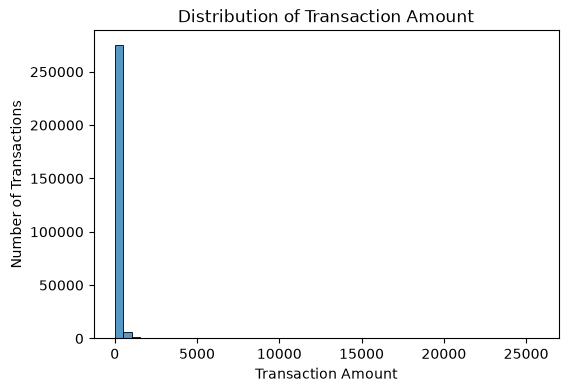

In [26]:
plt.figure(figsize=(6,4))

sns.histplot(data=df, x="Amount", bins=50)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount")
plt.ylabel("Number of Transactions")

plt.show()

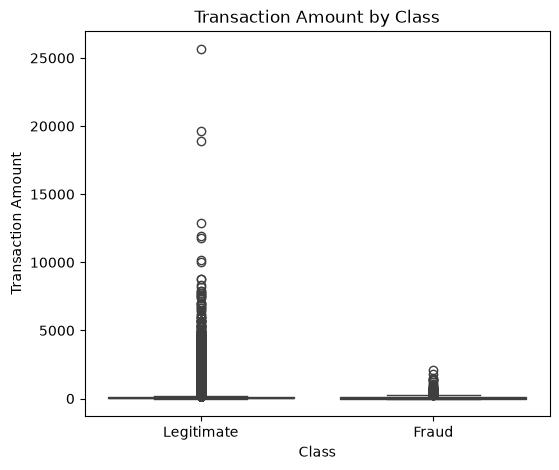

In [27]:
# Amount by Class

plt.figure(figsize=(6,5))

sns.boxplot(data=df, x="Class", y="Amount")

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Transaction Amount")

plt.xticks([0,1], ["Legitimate", "Fraud"])

plt.show()

In [28]:
# Amount statistics by transaction class

df.groupby("Class")["Amount"].describe()



,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,283253.0,88.413575,250.379023,0.0,5.67,22.00,77.46,25691.16
1,473.0,123.871860,260.211041,0.0,1.00,9.82,105.89,2125.87


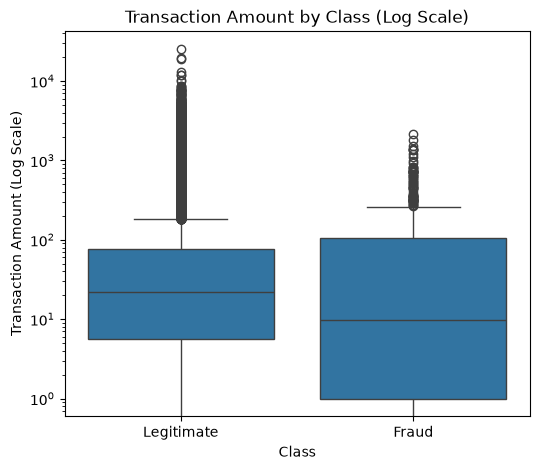

In [29]:
plt.figure(figsize=(6,5))

sns.boxplot(data=df, x="Class", y="Amount")

plt.yscale("log")

plt.title("Transaction Amount by Class (Log Scale)")
plt.xlabel("Class")
plt.ylabel("Transaction Amount (Log Scale)")

plt.xticks([0,1],["Legitimate", "Fraud"])

plt.show()



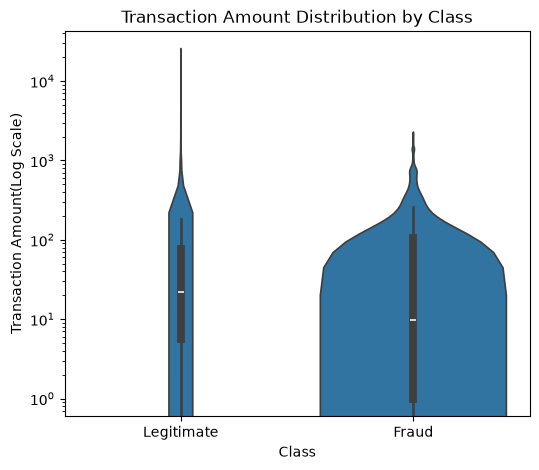

In [30]:
# Compare the distribution using violin plot

plt.figure(figsize=(6,5))

sns.violinplot(data=df, x="Class", y="Amount")

plt.yscale("log")

plt.title("Transaction Amount Distribution by Class")
plt.xlabel("Class")
plt.ylabel("Transaction Amount(Log Scale)")

plt.xticks([0,1], ["Legitimate", "Fraud"])

plt.show()

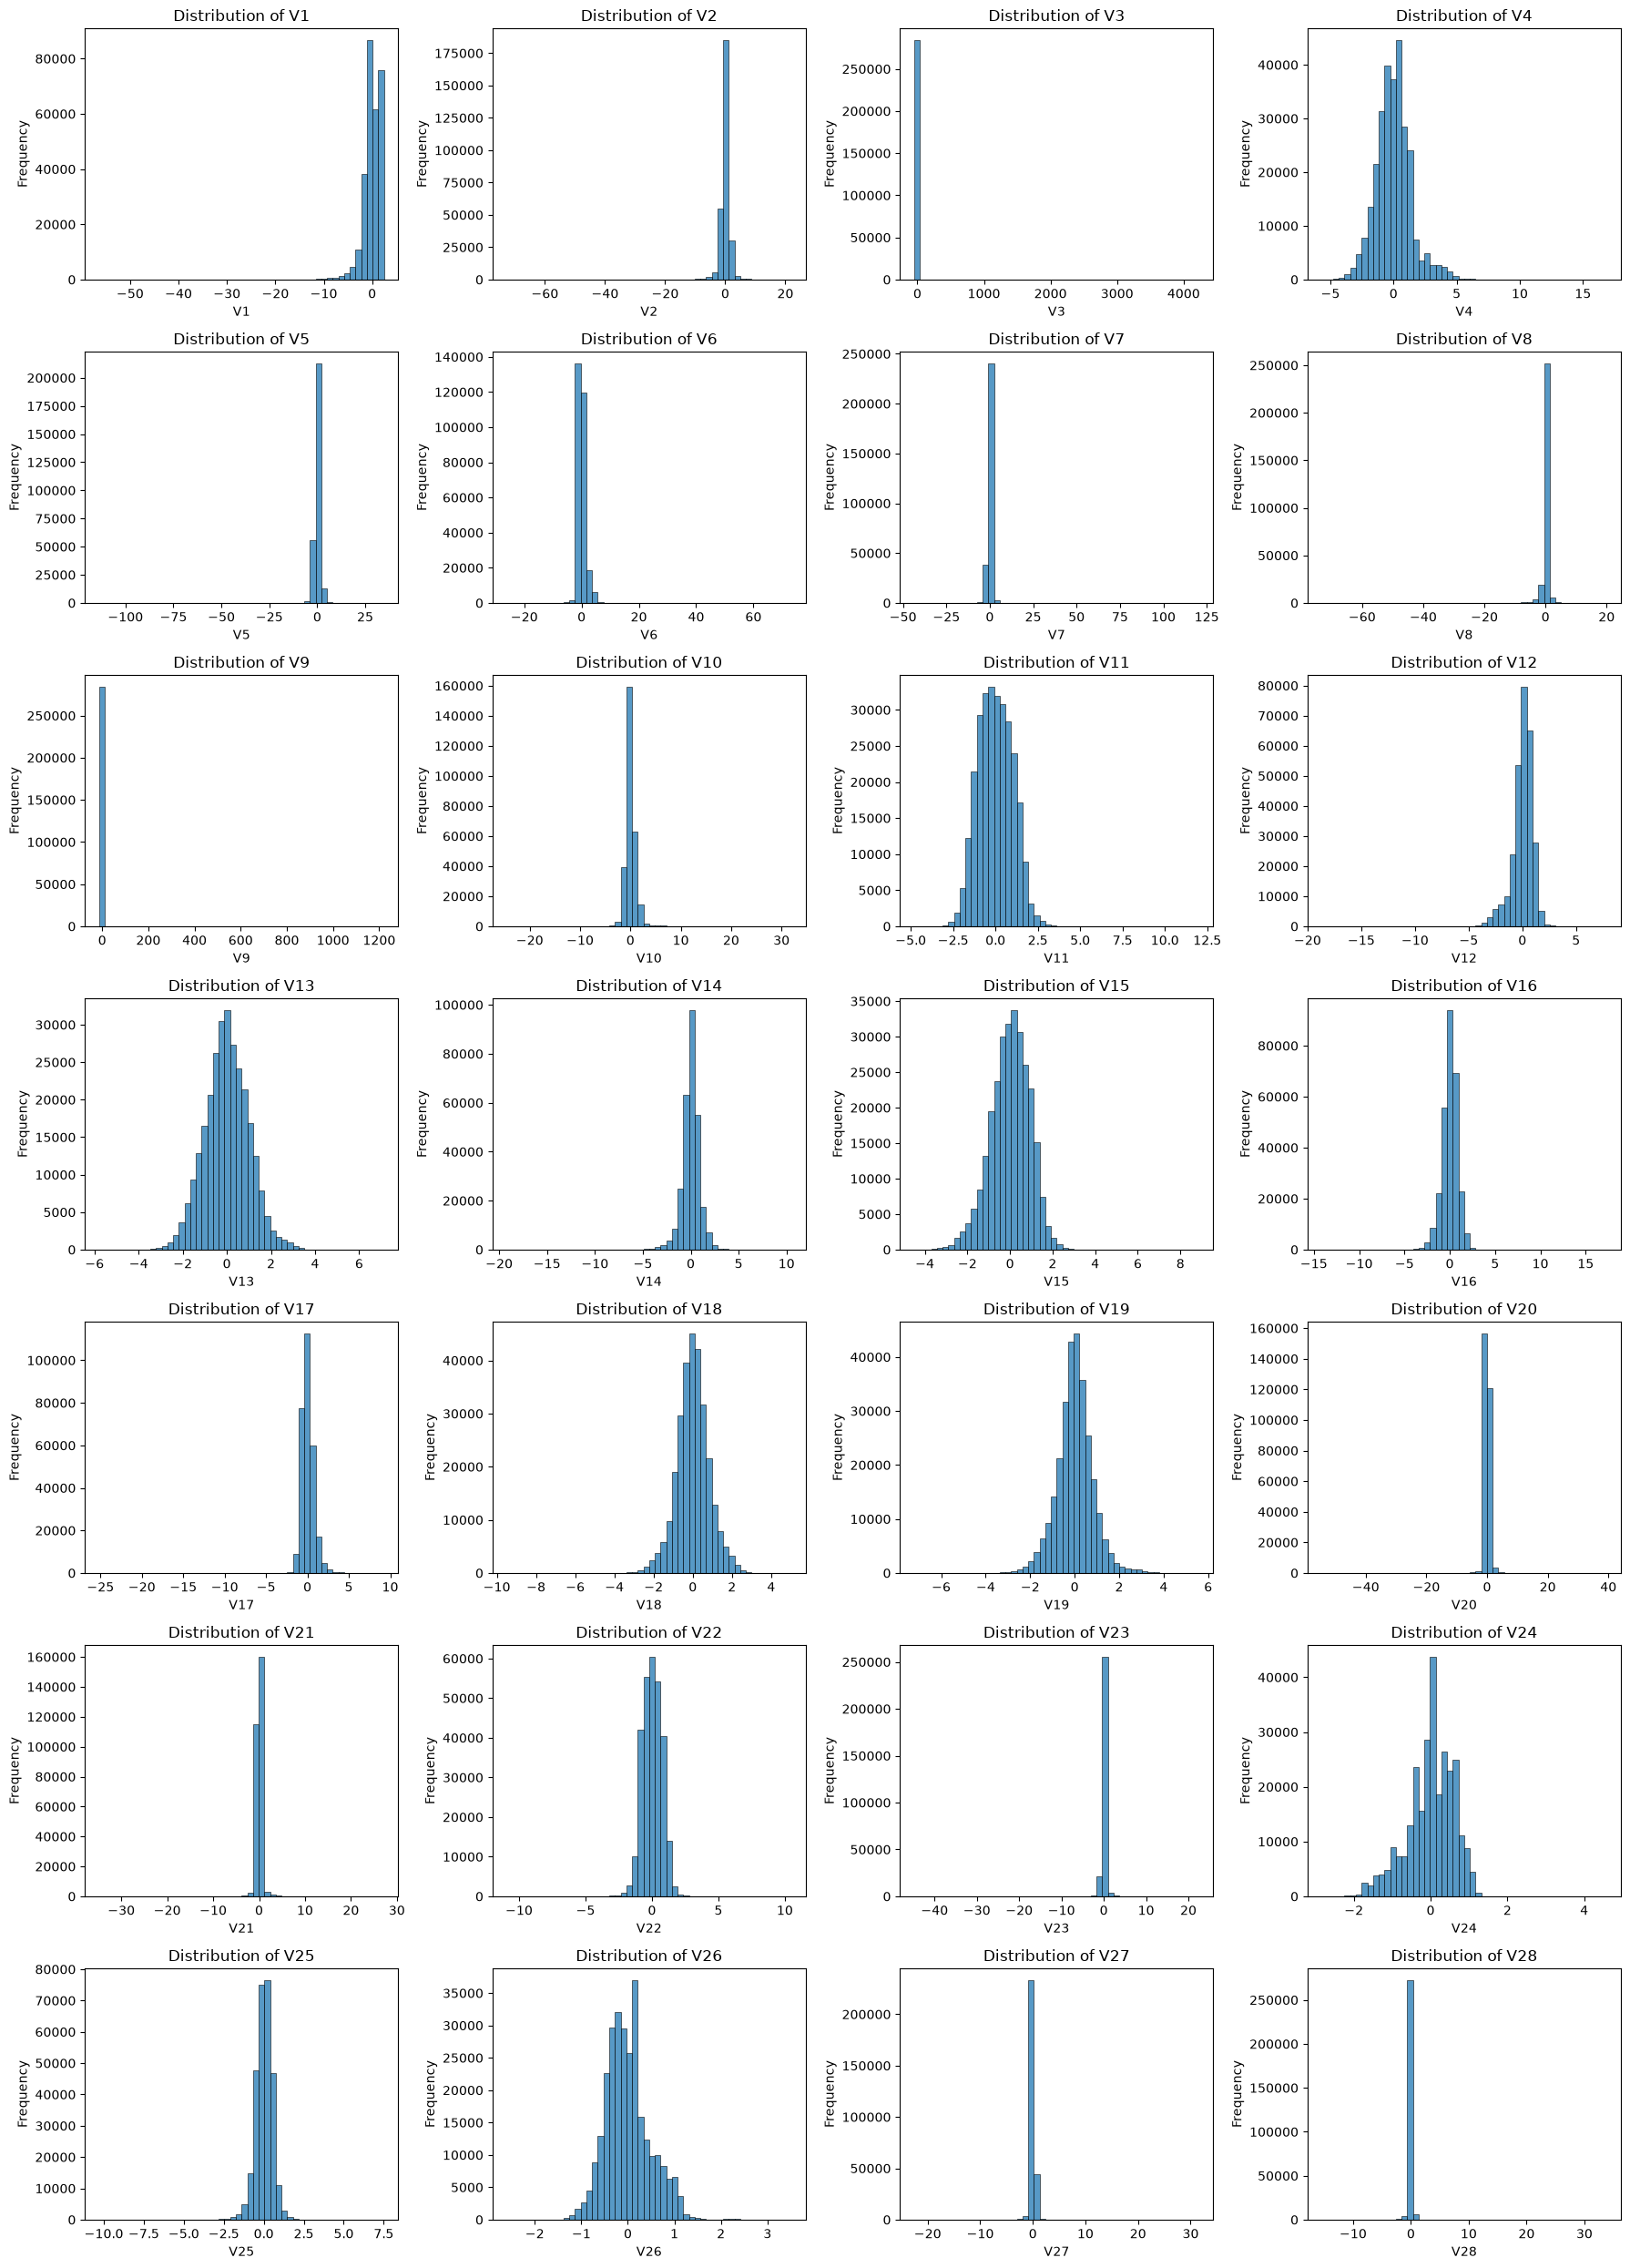

In [31]:
# Distribution of V1 to V28 features

features = [f"V{i}" for i in range(1, 29)]

fig, axes = plt.subplots(7, 4, figsize=(18, 25))

axes = axes.flatten()

for i, feature in enumerate(features):
    sns.histplot(
        data=df,
        x=feature,
        bins=50,
        ax=axes[i]
    )
    
    axes[i].set_title(f"Distribution of {feature}")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

Observation:

The PCA-transformed features V1–V28 exhibit different distribution patterns, 
including concentrated, skewed and relatively symmetric distributions. Several 
features contain extreme values or long tails. Since these features are 
anonymized PCA components, they cannot be interpreted individually from a 
business perspective. Further analysis comparing their distributions across 
fraudulent and legitimate transactions is required to identify potentially 
discriminative features.

In [32]:
# Mean of V1-V28 by transaction class

class_means = df.groupby("Class")[features].mean().T
class_means


Class,0,1
V1,0.013455,-4.498280
V2,-0.009821,3.405965
V3,0.027906,-6.729599
V4,-0.010417,4.472591
V5,0.006791,-2.957197
V6,0.001235,-1.432518
V7,0.010476,-5.175912
V8,-0.002445,0.953255
V9,0.006947,-2.522124
V10,0.007826,-5.453274


In [33]:
# Difference in means between legitimate and fraud transactions

mean_difference = (
    df[df["Class"]==1][features].mean() - df[df["Class"]==0][features].mean()
).abs().sort_values(ascending=False)

print("Features ranked  by absolute mean difference:")
print(mean_difference)

Features ranked  by absolute mean difference:
V14    6.847612
V3     6.757505
V17    6.474249
V12    6.112721
V10    5.461100
V7     5.186388
V1     4.511735
V4     4.483008
V16    4.008801
V11    3.722356
V2     3.415786
V5     2.963988
V9     2.529071
V18    2.162191
V6     1.433752
V8     0.955700
V19    0.670525
V21    0.467701
V20    0.405532
V27    0.212365
V24    0.107036
V23    0.096824
V13    0.095091
V22    0.086798
V28    0.077853
V15    0.073990
V26    0.050391
V25    0.040916
dtype: float64


In [34]:
# Correlation of features with the target variable

correlation_with_class = (df.corr(numeric_only=True)["Class"]
                           .drop("Class")
                           .sort_values(key=abs, ascending=False))

print("Correlation with class:")
print(correlation_with_class)


Correlation with class:
V17      -0.313498
V14      -0.293375
V12      -0.250713
V10      -0.206617
V16      -0.187186
V7       -0.172350
V11       0.149068
V4        0.129326
V18      -0.105340
V1       -0.094487
V5       -0.087814
V2        0.084625
V6       -0.043916
V9       -0.040611
V3       -0.034088
V19       0.033631
V8        0.033068
V21       0.026357
V27       0.021892
V20       0.021486
Time     -0.012359
V28       0.009682
V24      -0.007210
V23      -0.006333
Amount    0.005777
V22       0.004887
V26       0.004265
V13      -0.003897
V15      -0.003299
V25       0.003202
Name: Class, dtype: float64


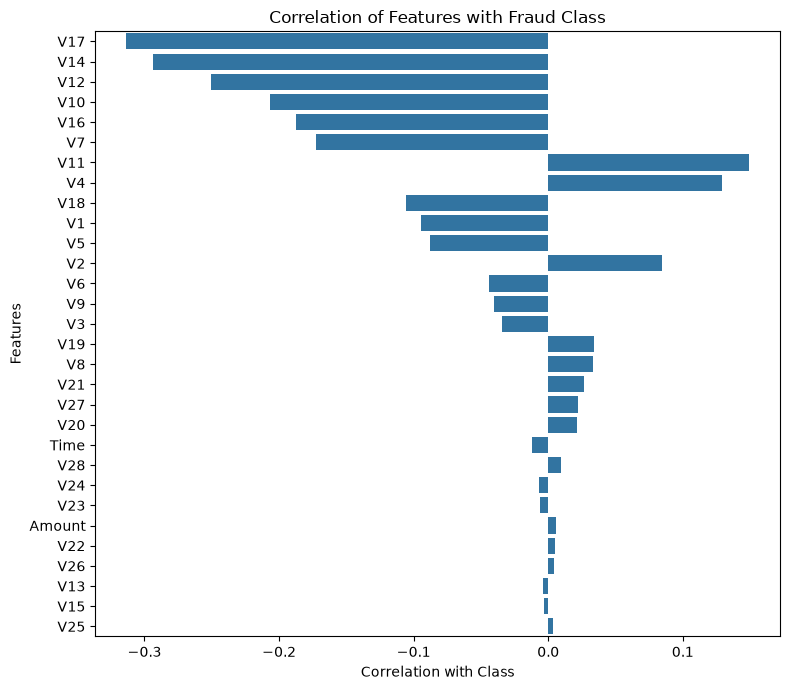

In [35]:
# Visualize correlation with class

plt.figure(figsize=(8,7))

sns.barplot(x=correlation_with_class.values,
            y=correlation_with_class.index)


plt.title("Correlation of Features with Fraud Class")
plt.xlabel("Correlation with Class")
plt.ylabel("Features")

plt.tight_layout()
plt.show()


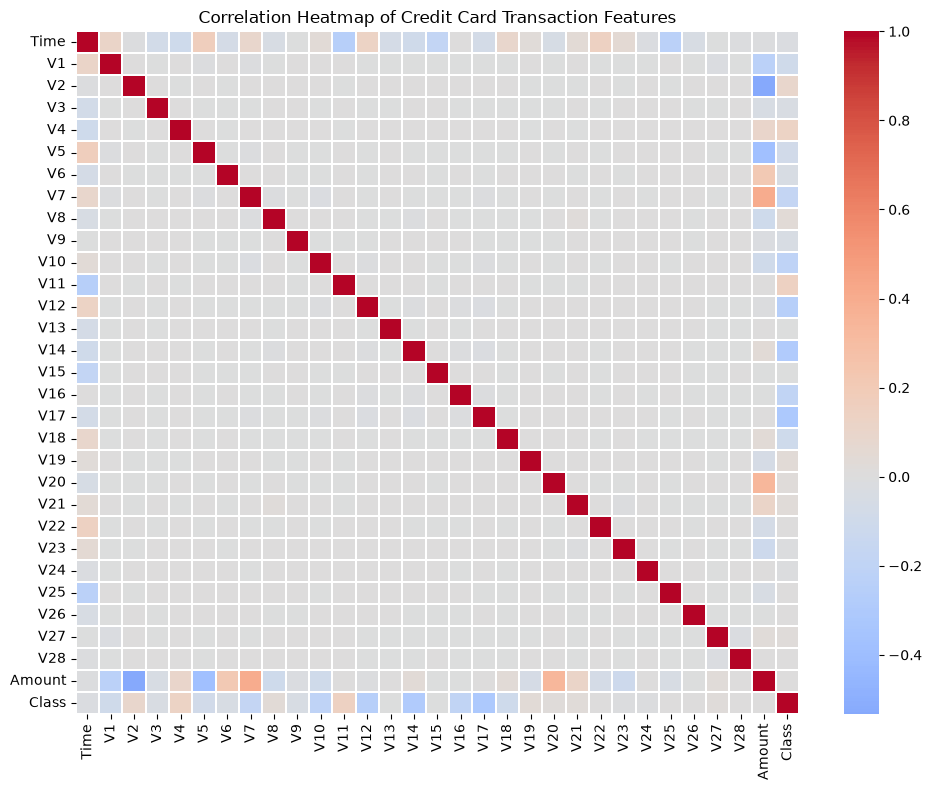

In [36]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Heatmap of Credit Card Transaction Features")

plt.tight_layout()
plt.show()

Observation:

Several PCA-transformed features show noticeable differences between legitimate 
and fraudulent transactions. V14, V3, V17, V12, V10, V7 and V16 have relatively 
large class-wise mean differences. V17, V14 and V12 also show comparatively 
strong correlations with the fraud class. Time and Amount have weak linear 
correlations with the target, although they may still provide useful nonlinear 
information to machine learning models. Therefore, feature importance will be 
evaluated further during model development rather than removing features solely 
based on correlation.

In [37]:
# Visualize the strongest features by class

# top features based on absolute correlation with class

top_features = correlation_with_class.abs().sort_values(ascending=False).head(6).index.tolist()

print("Top 6 features:")
print(top_features)

Top 6 features:
['V17', 'V14', 'V12', 'V10', 'V16', 'V7']


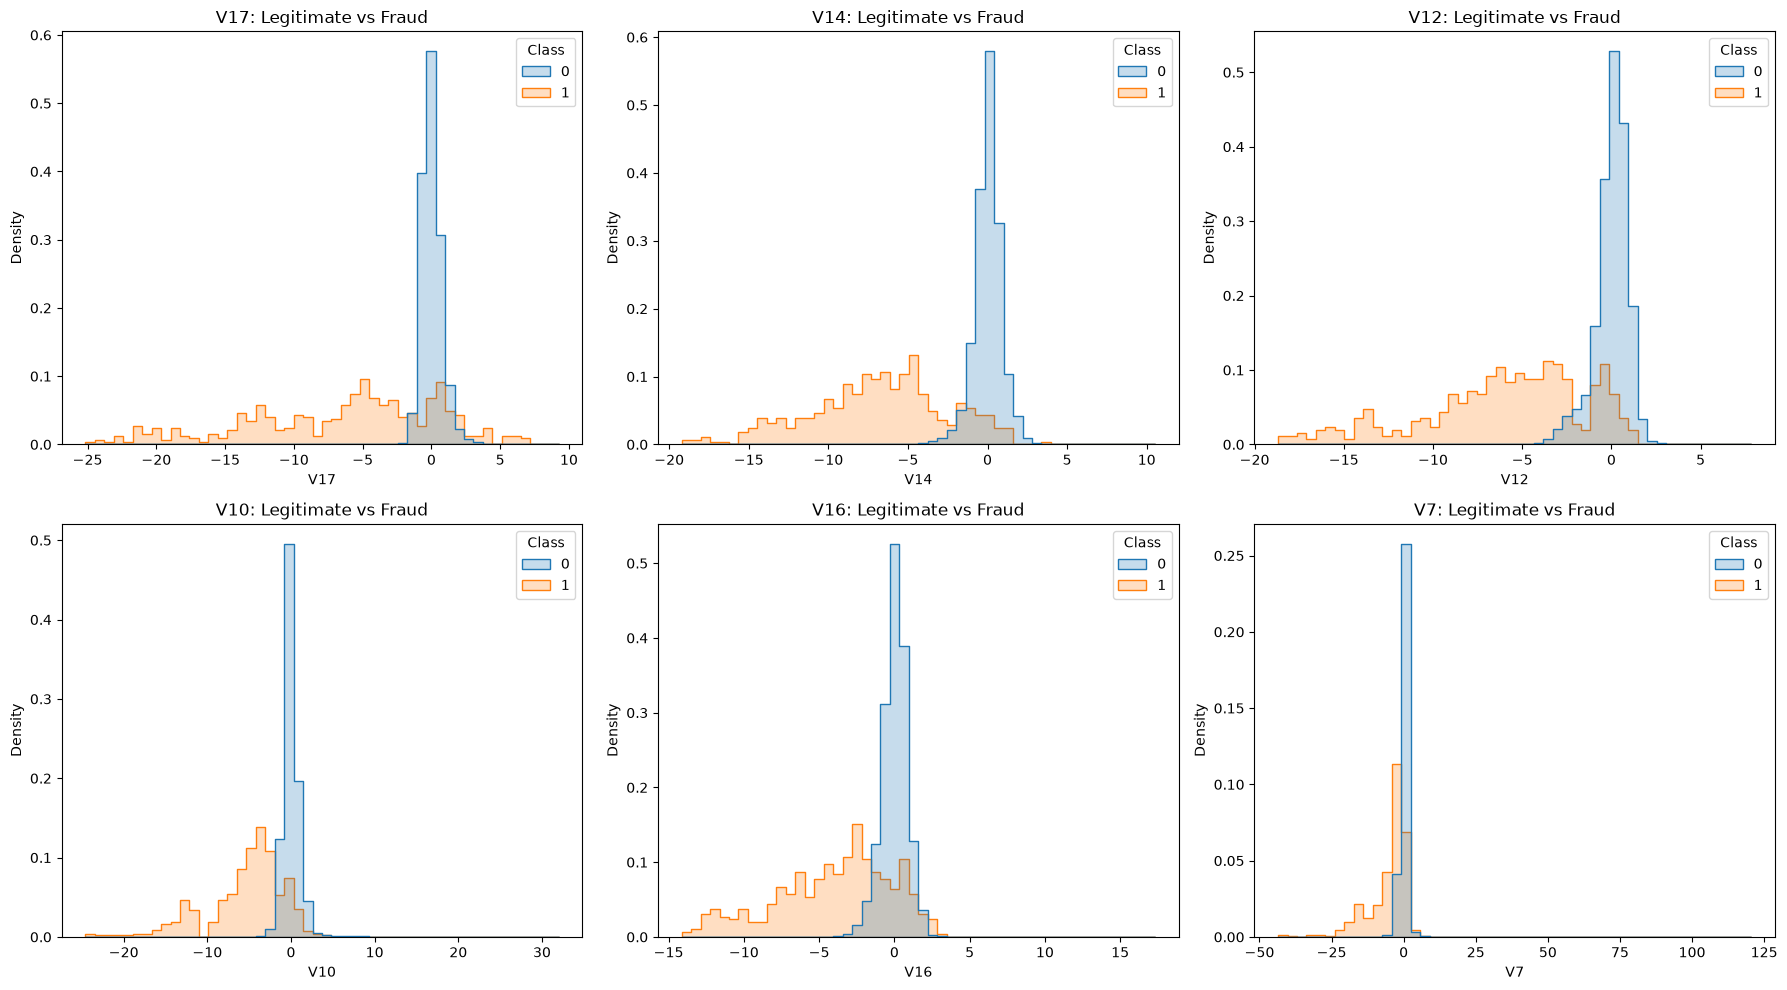

In [38]:
# Class wise distribution of top features

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.histplot(
        data=df,
        x=feature,
        hue="Class",
        bins=50,
        element="step",
        stat="density",
        common_norm=False,
        ax=axes[i]
    )
    
    axes[i].set_title(f"{feature}: Legitimate vs Fraud")
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel("Density")

plt.tight_layout()
plt.show()


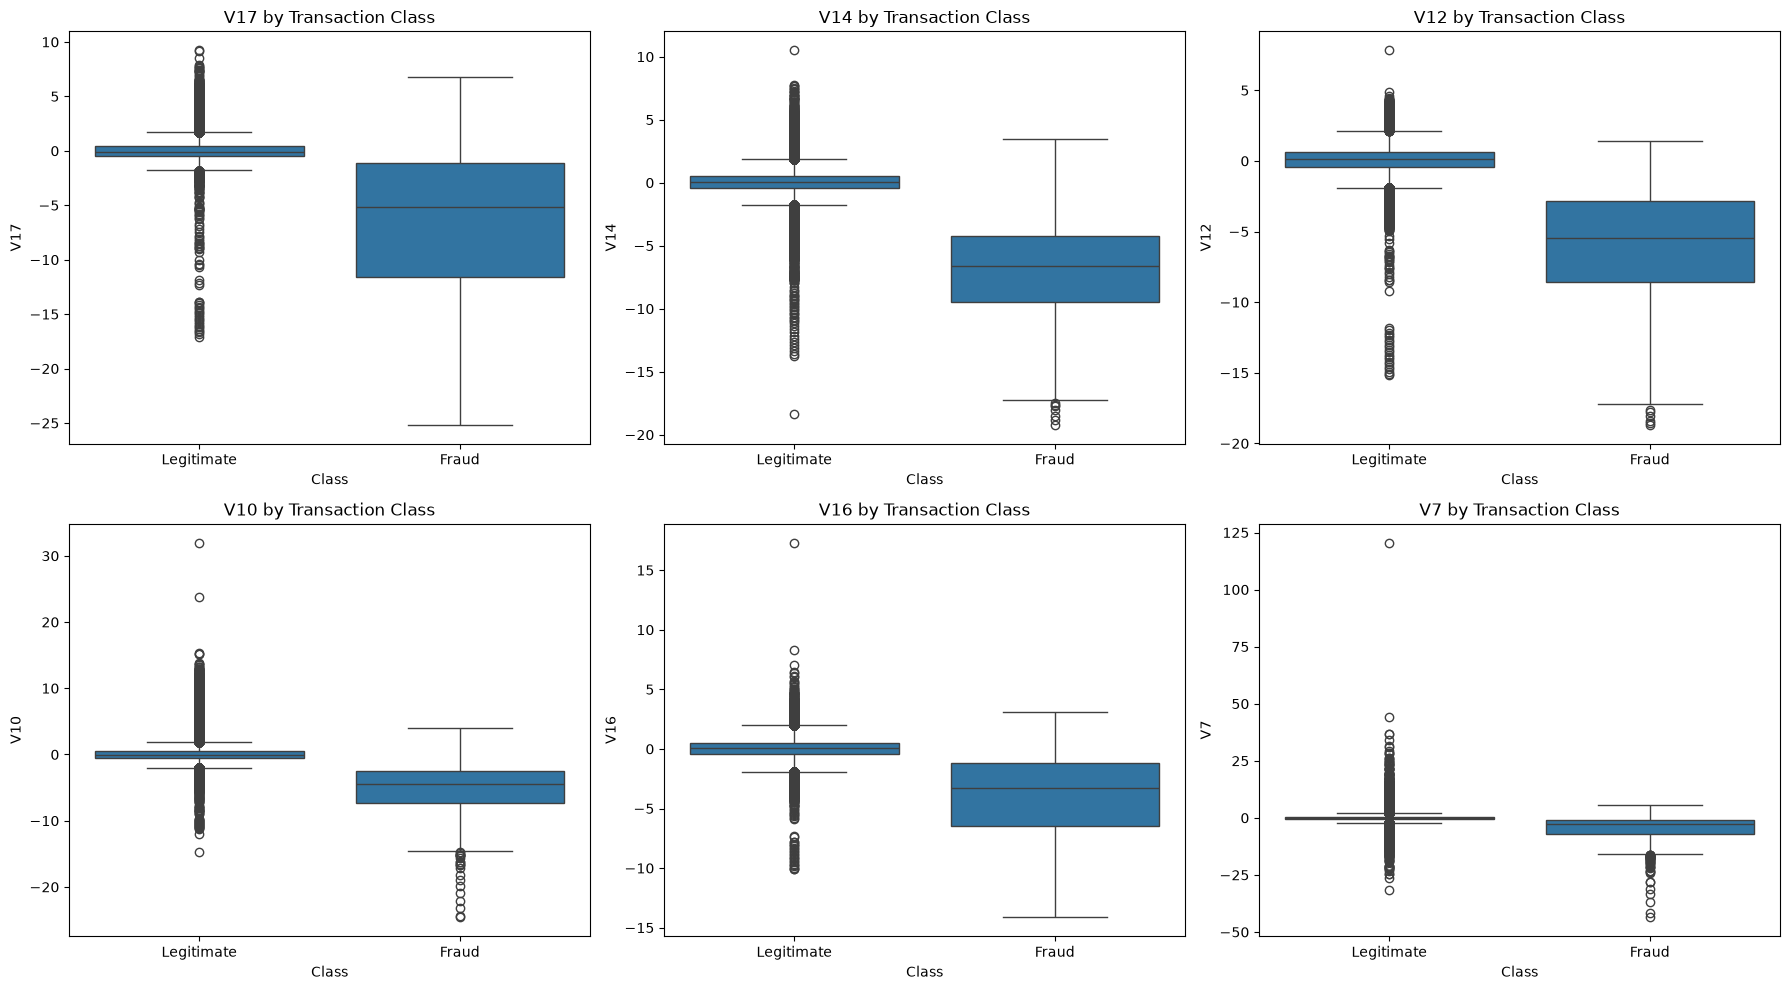

In [39]:
# Boxplots of the top features

fig, axes = plt.subplots(2, 3, figsize=(18,10))

axes = axes.flatten()

for i, feature in enumerate(top_features):
    sns.boxplot(data=df,
                x="Class",
                y=feature,
                ax=axes[i]
                )

    axes[i].set_title(f"{feature} by Transaction Class")
    axes[i].set_xlabel("Class")
    axes[i].set_ylabel(feature)
    axes[i].set_xticks([0,1])
    axes[i].set_xticklabels(["Legitimate", "Fraud"])


plt.tight_layout()
plt.show()


Observation:

The class-wise distributions of the top correlated PCA features show noticeable differences between legitimate and fraudulent transactions. Features such as V17, V14, V12, V10, V16 and V7 exhibit substantial shifts in their distributions and median values across the two classes. This indicates that these variables contain potentially useful discriminatory information for fraud detection. However, considerable overlap remains between the two classes, suggesting that fraud detection should rely on the combined information from multiple features rather than any single variable. The presence of extreme observations was also observed, but these were retained because they may represent genuine transaction patterns and could provide useful signals for fraud detection.

In [40]:
# Outlier Analysis

# Count outliers using IQR

outlier_counts = {}

numeric_features = df.drop(columns="Class").select_dtypes(include=np.number).columns

for column in numeric_features:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_counts[column] = len(outliers)

outlier_counts = pd.Series(outlier_counts).sort_values(ascending=False)

print("Number of potential outliers by feature:")
print(outlier_counts)

Number of potential outliers by feature:
V27       38799
Amount    31685
V28       30094
V20       27553
V8        23902
V6        22887
V23       18467
V12       15283
V21       14401
V14       14060
V2        13390
V5        12221
V4        11094
V19       10150
V10        9349
V7         8838
V9         8199
V16        8180
V18        7468
V17        7353
V1         6949
V26        5665
V25        5333
V24        4758
V13        3362
V3         3307
V15        2885
V22        1298
V11         735
Time          0
dtype: int64


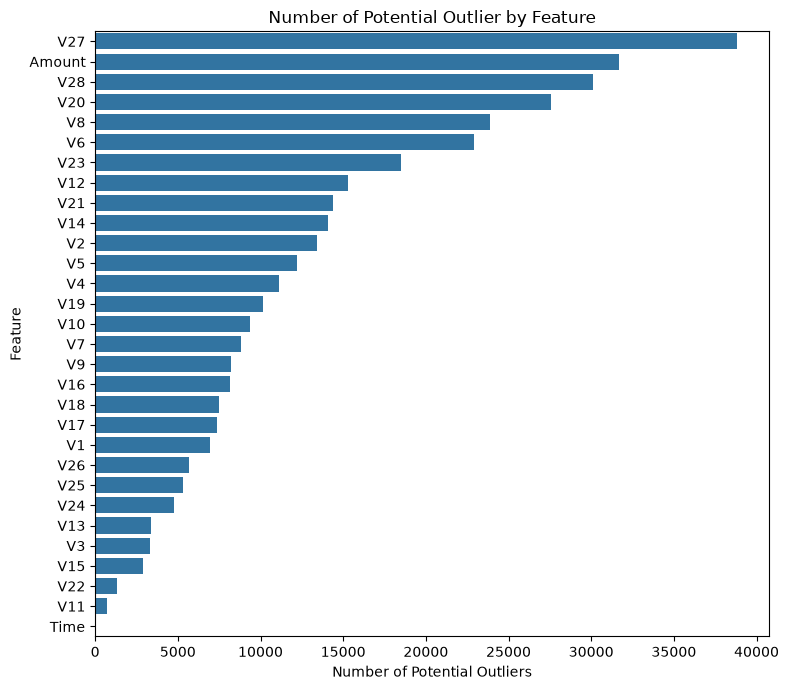

In [41]:
# Visualize the number of outliers

plt.figure(figsize=(8,7))

sns.barplot(
    x=outlier_counts.values,
    y=outlier_counts.index
)

plt.title("Number of Potential Outlier by Feature")
plt.xlabel("Number of Potential Outliers")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [42]:
# Compare outliers with fraud

# Outlier analysis by transaction class

outlier_class_counts = []

for column in df.select_dtypes(include=np.number).columns:
    if column=="Class":
        continue

    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)

    IQR = Q3-Q1

    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR

    outlier_mask = ((df[column] < lower_bound) | (df[column] > upper_bound))

    fraud_outliers = df.loc[outlier_mask & df["Class"] == 1].shape[0]

    legitimate_outliers = df.loc[outlier_mask & df["Class"] == 0].shape[0]

    outlier_class_counts.append({
        "Feature" : column,
        "Fraud_Outliers" : fraud_outliers,
        "Legitimate_Outliers" : legitimate_outliers
    })

    outlier_class_df = pd.DataFrame(outlier_class_counts)

    outlier_class_df.sort_values(by = "Fraud_Outliers", ascending = False)


Observation:

The dataset contains 283,726 transactions and 31 variables after removing 1,081 exact duplicate rows. No missing values were identified. The target variable is highly imbalanced, with 283,253 legitimate transactions and only 473 fraudulent transactions, representing approximately 99.83% and 0.17% of the dataset, respectively. The PCA-transformed features V1–V28 display varying distributions and several features, particularly V17, V14, V12, V10, V16 and V7, show noticeable differences between legitimate and fraudulent transactions. Potential statistical outliers were identified in several variables; however, they were retained because unusual observations may contain valuable information for fraud detection. These findings indicate that class imbalance, feature scaling and appropriate model evaluation will be important considerations during the modeling stage.

In [43]:
# Separate features and target

X = df.drop(columns="Class")
y = df["Class"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nFeature Columns:")
print(X.columns.tolist())

print("\nTraget Distribution:")
print(y.value_counts())

Feature Shape: (283726, 30)
Target Shape: (283726,)

Feature Columns:
['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Traget Distribution:
Class
0    283253
1       473
Name: count, dtype: int64


In [44]:
# Train Test split

# Before SMOTE

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set shape:", X_train.shape)
print("Testing set shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())



Training set shape: (226980, 30)
Testing set shape: (56746,)

Training target distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing target distribution:
Class
0    56651
1       95
Name: count, dtype: int64


In [45]:
print("\nTraining target percentage:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target percentage:")
print(y_test.value_counts(normalize=True) * 100)


Training target percentage:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Testing target percentage:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


In [46]:
# Feature Sacling

# Use Standard Scaler

scaler = StandardScaler()

#Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)


Scaled training shape: (226980, 30)
Scaled testing shape: (56746, 30)


In [47]:
# check the training the data

print("Training data mean:")
print(X_train_scaled.mean(axis=0))

print("\nTraining data standard deviation:")
print(X_train_scaled.std(axis=0))

Training data mean:
[-1.52263630e-16  1.36486313e-17 -3.50607042e-18  3.25563682e-18
 -1.50260161e-18 -5.94779803e-18  6.51127364e-18 -1.00173441e-18
  2.00346881e-18 -2.50433601e-18  2.25390241e-17 -1.65286177e-17
 -3.75650402e-18  2.19129401e-17 -1.46503657e-17 -1.12695121e-18
  1.13008163e-17  1.74051353e-17 -1.60277505e-17  7.01214084e-18
 -4.00693762e-18 -7.01214084e-18  1.10190785e-17 -1.75303521e-18
  2.12868561e-17 -1.65286177e-17 -2.10364225e-17 -8.51474245e-18
  1.69042681e-18  7.48796468e-17]

Training data standard deviation:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


Observation:

StandardScaler was applied to the predictor variables after splitting the dataset into training and testing sets. The training features have a mean approximately equal to 0 and a standard deviation of 1, confirming that the standardization was performed successfully. The scaler was fitted only on the training data and subsequently used to transform the test data, preventing data leakage.

In [48]:
print("Training set class distribution:")
print(y_train.value_counts())

print("\nTraining set class percentage:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting set class distribution:")
print(y_test.value_counts())

print("\nTesting set class percentage:")
print(y_test.value_counts(normalize=True) * 100)

Training set class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Training set class percentage:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Testing set class distribution:
Class
0    56651
1       95
Name: count, dtype: int64

Testing set class percentage:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


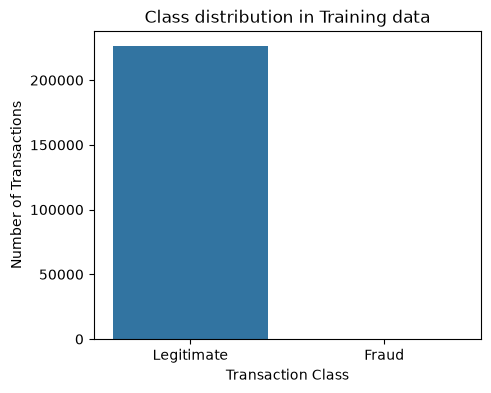

In [49]:
# Visualize class distribution in the training data

plt.figure(figsize=(5,4))

sns.countplot(x=y_train)

plt.title("Class distribution in Training data")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.xticks([0,1], ["Legitimate", "Fraud"])
plt.show()

Observation:

The training dataset exhibits severe class imbalance, with 226,602 legitimate transactions compared with only 378 fraudulent transactions. Fraudulent transactions represent approximately 0.17% of the training data. Therefore, relying solely on accuracy may produce misleading results, and appropriate class-imbalance handling and fraud-focused evaluation metrics such as precision, recall, F1-score and PR-AUC are required.

In [50]:
# Baseline Logistic Regression

lr_baseline = LogisticRegression(
    max_iter = 1000,
    random_state=42

)

lr_baseline.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [51]:
# Prediction

y_pred_lr = lr_baseline.predict(X_test_scaled)

y_prob_lr = lr_baseline.predict_proba(X_test_scaled)[:, 1]

In [52]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

print("Logistic Regression - Baseline")

print("\nAccuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))
print("PR-AUC:", average_precision_score(y_test, y_prob_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression - Baseline

Accuracy: 0.9991188806259472
Precision: 0.8461538461538461
Recall: 0.5789473684210527
F1 Score: 0.6875
ROC-AUC: 0.9555604072581056
PR-AUC: 0.6908828166952131

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746



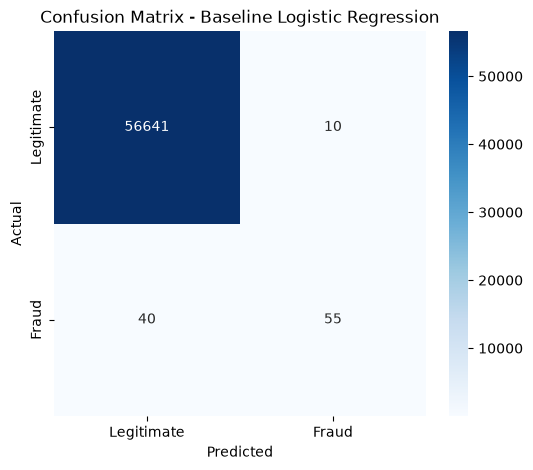

In [53]:
cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Observation:

Baseline Logistic Regression: The baseline Logistic Regression model achieved an accuracy of 99.91% and ROC-AUC of 95.56%. However, due to the highly imbalanced nature of the dataset, accuracy alone is not sufficient to evaluate fraud detection performance. The model achieved 84.62% precision but only 57.89% recall, indicating that while most transactions predicted as fraudulent were actually fraud, a considerable number of fraudulent transactions were missed. The confusion matrix shows 55 true positives and 40 false negatives. Therefore, improving fraud detection recall while maintaining acceptable precision will be an important objective in subsequent modeling stages.

In [54]:
# Decision Tree Baseline

dt_baseline = DecisionTreeClassifier(
    random_state=42
)

dt_baseline.fit(X_train, y_train)

y_pred_dt = dt_baseline.predict(X_test)
y_prob_dt = dt_baseline.predict_proba(X_test)[:, 1]

In [55]:
print("Decision Tree - Baseline")

print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_dt))
print("PR-AUC:", average_precision_score(y_test, y_prob_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree - Baseline
Accuracy: 0.999048391076023
Precision: 0.7204301075268817
Recall: 0.7052631578947368
F1 Score: 0.7127659574468085
ROC-AUC: 0.8524021037395169
PR-AUC: 0.508586239526323

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.72      0.71      0.71        95

    accuracy                           1.00     56746
   macro avg       0.86      0.85      0.86     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56625    26]
 [   28    67]]


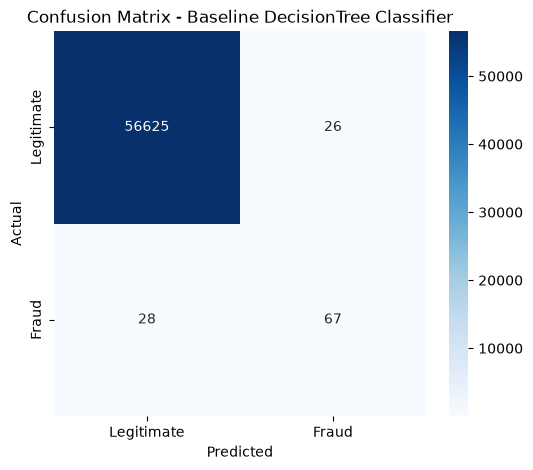

In [56]:
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Confusion Matrix - Baseline DecisionTree Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Observation:

The Decision Tree achieved an accuracy of 99.90%, with a precision of 72.04%, recall of 70.53%, and F1-score of 71.28%. Compared with Logistic Regression, the Decision Tree identified more fraudulent transactions, increasing recall from 57.89% to 70.53%. However, this improvement came at the cost of lower precision. The model produced 67 true positives and 28 false negatives, indicating better fraud detection coverage than the Logistic Regression baseline. Nevertheless, its lower ROC-AUC and PR-AUC suggest that further model improvement and imbalance-handling techniques should be explored.

In [57]:
# Random Forest Baseline

rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_baseline.fit(X_train, y_train)

y_pred_rf = rf_baseline.predict(X_test)
y_prob_rf = rf_baseline.predict_proba(X_test)[:, 1]

In [58]:
print("Random Forest - Baseline")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest - Baseline
Accuracy: 0.9995065731505305
Precision: 0.971830985915493
Recall: 0.7263157894736842
F1 Score: 0.8313253012048193
ROC-AUC: 0.9239484786351149
PR-AUC: 0.7875758110273144

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56649     2]
 [   26    69]]


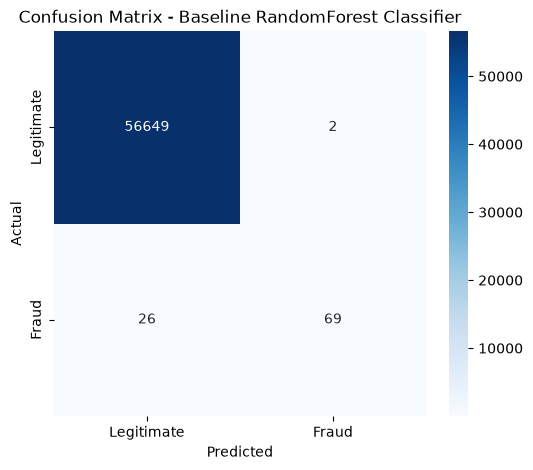

In [59]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Confusion Matrix - Baseline RandomForest Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Observation:

The Random Forest model achieved an accuracy of 99.95%, precision of 97.18%, recall of 72.63%, and F1-score of 83.13%. It correctly identified 69 fraudulent transactions while missing 26 fraudulent transactions and incorrectly classifying only 2 legitimate transactions as fraud. Compared with Logistic Regression and Decision Tree, Random Forest provided the best balance between precision and recall and achieved the highest PR-AUC of 78.76%. These results indicate that Random Forest is a strong baseline candidate for the subsequent imbalance-handling and model optimization stages.

In [60]:
# KNN Baseline

knn_baseline = KNeighborsClassifier(
    n_neighbors=5
)

knn_baseline.fit(X_train_scaled, y_train)

y_pred_knn = knn_baseline.predict(X_test_scaled)
y_prob_knn = knn_baseline.predict_proba(X_test_scaled)[:, 1]

In [61]:
print("KNN - Baseline")

print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_knn))
print("PR-AUC:", average_precision_score(y_test, y_prob_knn))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_knn))

KNN - Baseline
Accuracy: 0.9993832164381631
Precision: 0.9545454545454546
Recall: 0.6631578947368421
F1 Score: 0.782608695652174
ROC-AUC: 0.8998550682897779
PR-AUC: 0.7680823699050965

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.66      0.78        95

    accuracy                           1.00     56746
   macro avg       0.98      0.83      0.89     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56648     3]
 [   32    63]]


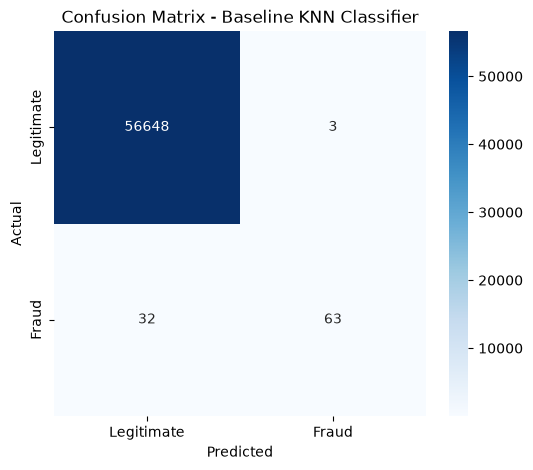

In [62]:
cm = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Confusion Matrix - Baseline KNN Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Observation:

The KNN model achieved an accuracy of 99.94%, precision of 95.45%, recall of 66.32%, and F1-score of 78.26%. It correctly identified 63 fraudulent transactions while generating only 3 false positives. Although KNN demonstrated high precision, its recall was lower than that of the Random Forest model. Its PR-AUC of 76.81% was also slightly below Random Forest's 78.76%. Therefore, KNN performed well as a baseline but was not the strongest model among the models evaluated so far.

In [63]:
# Train LinearSVC Baseline

svm_baseline = LinearSVC(
    random_state=42,
    max_iter=1000
)

svm_baseline.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forthe dual coordinate descent (if ``dual=True``). When ``dual=False`` theunderlying implementation of :class:`LinearSVC` is not random and``random_state`` has no effect on the results.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adj

In [64]:
# Make Predictions

y_pred_svm = svm_baseline.predict(X_test_scaled)
y_score_svm = svm_baseline.decision_function(X_test_scaled)

In [65]:
# Evaluate the model

print("LinearSVC - Baseline")

print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall:", recall_score(y_test, y_pred_svm))
print("F1 Score:", f1_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_score_svm))
print("PR-AUC:", average_precision_score(y_test, y_score_svm))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))

LinearSVC - Baseline
Accuracy: 0.9991188806259472
Precision: 0.8688524590163934
Recall: 0.5578947368421052
F1 Score: 0.6794871794871795
ROC-AUC: 0.944792538618262
PR-AUC: 0.7145539564348921

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.56      0.68        95

    accuracy                           1.00     56746
   macro avg       0.93      0.78      0.84     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56643     8]
 [   42    53]]


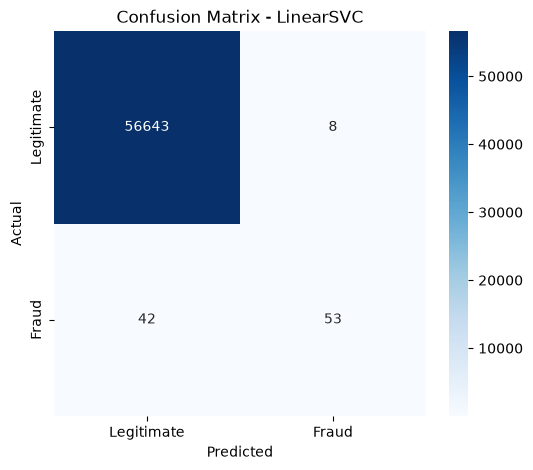

In [66]:
# Confusion matrix

cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - LinearSVC")
plt.show()

Observation:
 
The LinearSVC model achieved an accuracy of 99.91%, precision of 86.89%, recall of 55.79%, and F1-score of 67.95%. The model correctly detected 53 fraudulent transactions while missing 42 fraud cases. Although it maintained relatively high precision and achieved a strong ROC-AUC of 94.48%, its recall was lower than the Decision Tree, Random Forest, and KNN models. Therefore, LinearSVC did not provide the best baseline performance for the fraud detection task.

In [67]:
# Gradient Boosting

gb_baseline = GradientBoostingClassifier(
    random_state=42
)

gb_baseline.fit(X_train, y_train)

y_pred_gb = gb_baseline.predict(X_test)
y_prob_gb = gb_baseline.predict_proba(X_test)[:, 1]

In [68]:
print("Gradient Boosting - Baseline")

print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb))
print("Recall:", recall_score(y_test, y_pred_gb))
print("F1 Score:", f1_score(y_test, y_pred_gb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_gb))
print("PR-AUC:", average_precision_score(y_test, y_prob_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

Gradient Boosting - Baseline
Accuracy: 0.9992422373383146
Precision: 0.8611111111111112
Recall: 0.6526315789473685
F1 Score: 0.7425149700598802
ROC-AUC: 0.8539261164154671
PR-AUC: 0.6233542486597701

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.86      0.65      0.74        95

    accuracy                           1.00     56746
   macro avg       0.93      0.83      0.87     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56641    10]
 [   33    62]]


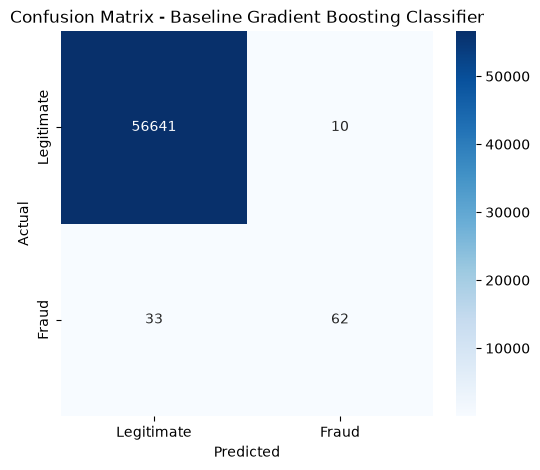

In [69]:
cm = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Confusion Matrix - Baseline Gradient Boosting Classifier")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Observation:

The Gradient Boosting model achieved an accuracy of 99.92%, precision of 86.11%, recall of 65.26%, and F1-score of 74.25%. It correctly identified 62 fraudulent transactions while missing 33 fraud cases and generated 10 false positives. Although the model performed better than Logistic Regression and LinearSVC in terms of F1-score, its PR-AUC of 62.34% and ROC-AUC of 85.39% were lower than those of several other baseline models. Therefore, Gradient Boosting demonstrated moderate performance but did not outperform Random Forest or KNN.

In [70]:
# XGBoost

xgb_baseline = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_baseline.fit(X_train, y_train)

y_pred_xgb = xgb_baseline.predict(X_test)
y_prob_xgb = xgb_baseline.predict_proba(X_test)[:, 1]

In [71]:
print("XGboost - Baseline")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall:", recall_score(y_test, y_pred_xgb))
print("F1 Score:", f1_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGboost - Baseline
Accuracy: 0.9992422373383146
Precision: 0.8170731707317073
Recall: 0.7052631578947368
F1 Score: 0.7570621468926554
ROC-AUC: 0.8474525929304914
PR-AUC: 0.6648548815860287

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.82      0.71      0.76        95

    accuracy                           1.00     56746
   macro avg       0.91      0.85      0.88     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56636    15]
 [   28    67]]


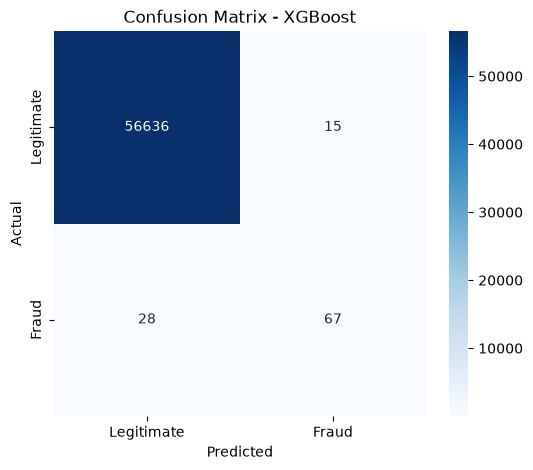

In [72]:
cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [73]:
# Baseline Model Comparison

baseline_results = {
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr),
        roc_auc_score(y_test, y_prob_lr),
        average_precision_score(y_test, y_prob_lr)
    ],
    
    "Decision Tree": [
        accuracy_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_dt),
        roc_auc_score(y_test, y_prob_dt),
        average_precision_score(y_test, y_prob_dt)
    ],
    
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_prob_rf),
        average_precision_score(y_test, y_prob_rf)
    ],
    
    "KNN": [
        accuracy_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_knn),
        roc_auc_score(y_test, y_prob_knn),
        average_precision_score(y_test, y_prob_knn)
    ],
    
    "LinearSVC": [
        accuracy_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm),
        roc_auc_score(y_test, y_score_svm),
        average_precision_score(y_test, y_score_svm)
    ],
    
    "Gradient Boosting": [
        accuracy_score(y_test, y_pred_gb),
        precision_score(y_test, y_pred_gb),
        recall_score(y_test, y_pred_gb),
        f1_score(y_test, y_pred_gb),
        roc_auc_score(y_test, y_prob_gb),
        average_precision_score(y_test, y_prob_gb)
    ],
    
    "XGBoost": [
        accuracy_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_xgb),
        roc_auc_score(y_test, y_prob_xgb),
        average_precision_score(y_test, y_prob_xgb)
    ]
}

baseline_comparison = pd.DataFrame(
    baseline_results,
    index=[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC"
    ]
).T

# Display percentages
baseline_comparison_percentage = baseline_comparison * 100

print("Baseline Model Comparison (%)")
display(baseline_comparison_percentage.round(2))

Baseline Model Comparison (%)


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Logistic Regression,99.91,84.62,57.89,68.75,95.56,69.09
Decision Tree,99.90,72.04,70.53,71.28,85.24,50.86
Random Forest,99.95,97.18,72.63,83.13,92.39,78.76
KNN,99.94,95.45,66.32,78.26,89.99,76.81
LinearSVC,99.91,86.89,55.79,67.95,94.48,71.46
Gradient Boosting,99.92,86.11,65.26,74.25,85.39,62.34
XGBoost,99.92,81.71,70.53,75.71,84.75,66.49


### Handling Class Imbalance

In [74]:
# Train weighted Random Forest

rf_weighted = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_weighted.fit(X_train, y_train)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_fe

In [75]:
# Predcitions

y_pred_rf_weighted = rf_weighted.predict(X_test)

y_prob_rf_weighted = rf_weighted.predict_proba(X_test)[:, 1]

In [76]:
# Evaluate

print("Random Forest - Class Weighted")

print("Accuracy:", accuracy_score(y_test, y_pred_rf_weighted))
print("Precision:", precision_score(y_test, y_pred_rf_weighted))
print("Recall:", recall_score(y_test, y_pred_rf_weighted))
print("F1 Score:", f1_score(y_test, y_pred_rf_weighted))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_weighted))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf_weighted))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_weighted))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_weighted))

Random Forest - Class Weighted
Accuracy: 0.9994713283755683
Precision: 0.9452054794520548
Recall: 0.7263157894736842
F1 Score: 0.8214285714285714
ROC-AUC: 0.9390625333877138
PR-AUC: 0.8005343094525127

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.95      0.73      0.82        95

    accuracy                           1.00     56746
   macro avg       0.97      0.86      0.91     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56647     4]
 [   26    69]]


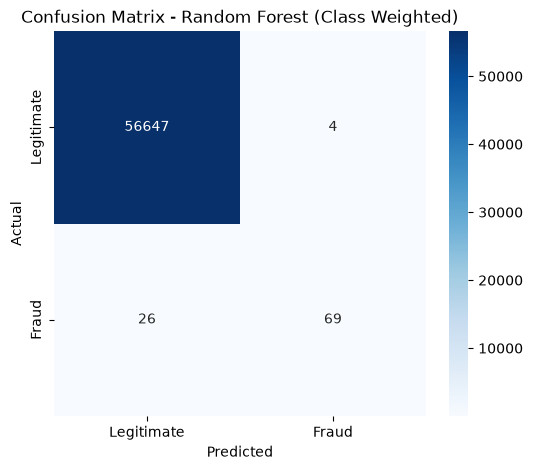

In [77]:
# Confusion Matrix Visualization

cm_rf_weighted = confusion_matrix(y_test, y_pred_rf_weighted)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf_weighted,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest (Class Weighted)")
plt.show()

In [78]:
# Random Forest + SMOTE

smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [79]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


In [80]:
# Train Random Forest on SMOTE data

rf_smote = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_smote.fit(X_train_smote, y_train_smote)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [81]:
y_pred_rf_smote = rf_smote.predict(X_test)

y_prob_rf_smote = rf_smote.predict_proba(X_test)[:, 1]

In [82]:
print("Random Forest - SMOTE")

print("Accuracy:", accuracy_score(y_test, y_pred_rf_smote))
print("Precision:", precision_score(y_test, y_pred_rf_smote))
print("Recall:", recall_score(y_test, y_pred_rf_smote))
print("F1 Score:", f1_score(y_test, y_pred_rf_smote))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf_smote))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf_smote))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_smote))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf_smote))

Random Forest - SMOTE
Accuracy: 0.9994537059880872
Precision: 0.8902439024390244
Recall: 0.7684210526315789
F1 Score: 0.8248587570621468
ROC-AUC: 0.9608860901791113
PR-AUC: 0.8054665993698316

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.89      0.77      0.82        95

    accuracy                           1.00     56746
   macro avg       0.94      0.88      0.91     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56642     9]
 [   22    73]]


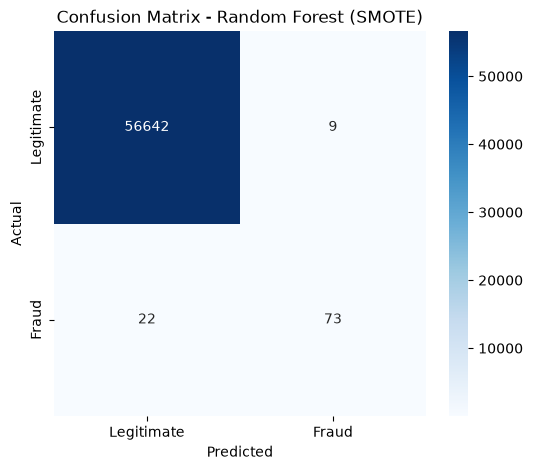

In [83]:
cm_rf_smote = confusion_matrix(y_test, y_pred_rf_smote)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf_smote,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest (SMOTE)")
plt.show()

Random Forest with SMOTE: SMOTE was applied only to the training data to address the severe class imbalance. The resulting Random Forest model achieved 89.02% precision, 76.84% recall, and an F1-score of 82.49%. Compared with the baseline Random Forest, recall increased from 72.63% to 76.84%, while false negatives decreased from 26 to 22. The model also achieved improved ROC-AUC of 96.09% and PR-AUC of 80.55%. However, precision decreased from 97.18% to 89.02%, with false positives increasing from 2 to 9. This demonstrates the trade-off between detecting more fraudulent transactions and generating additional false alerts.

In [84]:
# Calculate class weight

scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]

print("Scale Pos Weight:", scale_pos_weight)

Scale Pos Weight: 599.4761904761905


In [85]:
# Train XGBoost with class weight

xgb_weighted = XGBClassifier(
    n_estimators=100,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_weighted.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [86]:
# Predcition

y_pred_xgb_weighted = xgb_weighted.predict(X_test)

y_prob_xgb_weighted = xgb_weighted.predict_proba(X_test)[:, 1]

In [87]:
# Evaluate

print("XGBoost - Class Weighted")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb_weighted))
print("Precision:", precision_score(y_test, y_pred_xgb_weighted))
print("Recall:", recall_score(y_test, y_pred_xgb_weighted))
print("F1 Score:", f1_score(y_test, y_pred_xgb_weighted))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_weighted))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb_weighted))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_weighted))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_weighted))

XGBoost - Class Weighted
Accuracy: 0.9995946850879357
Precision: 0.9615384615384616
Recall: 0.7894736842105263
F1 Score: 0.8670520231213873
ROC-AUC: 0.9757776375945424
PR-AUC: 0.8233338095428951

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.96      0.79      0.87        95

    accuracy                           1.00     56746
   macro avg       0.98      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56648     3]
 [   20    75]]


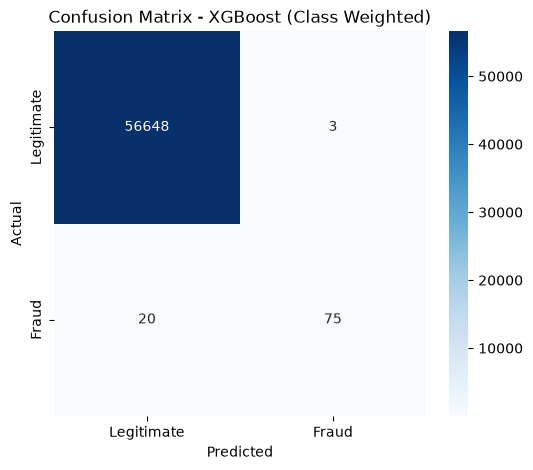

In [88]:
# Confusion Matrix

cm_xgb_weighted = confusion_matrix(y_test, y_pred_xgb_weighted)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb_weighted,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - XGBoost (Class Weighted)")
plt.show()

To address class imbalance, the scale_pos_weight parameter was applied to XGBoost using the class distribution of the training data. The class-weighted XGBoost model achieved 99.96% accuracy, 96.15% precision, 78.95% recall, and an F1-score of 86.71%. It correctly detected 75 of the 95 fraudulent transactions while generating only 3 false positives. Compared with the baseline XGBoost model, recall improved from 70.53% to 78.95%, while false negatives decreased from 28 to 20. ROC-AUC and PR-AUC also improved substantially to 97.58% and 82.33%, respectively. These results indicate that class weighting significantly improved XGBoost's ability to identify fraudulent transactions while maintaining high precision.

### Hyperparameter Tuning

In [89]:
param_dist_xgb = {
    "n_estimators": randint(100, 401),
    "max_depth": randint(3, 9),
    "learning_rate": uniform(0.01, 0.19),
    "min_child_weight": randint(1, 10),
    "subsample": uniform(0.7, 0.3),
    "colsample_bytree": uniform(0.7, 0.3),
    "gamma": uniform(0, 0.5)
}

In [90]:
# Create XGBosst Model

xgb_tuning = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

In [91]:
# Crreate RandomizedSearchCV

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_tuning,
    param_distributions=param_dist_xgb,
    n_iter=10,
    scoring="average_precision",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)



In [92]:
# Run the Tuning

xgb_random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....0020CC3FE2ED0>, 'gamma': <scipy.stats....0020CC3FE11C0>, 'learning_rate': <scipy.stats....0020CC5EE20F0>, 'max_depth': <scipy.stats....0020CC5AFA9F0>, ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",2
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score

In [93]:
# Get the best parameters

print("Best Parameters:")
print(xgb_random_search.best_params_)

Best Parameters:
{'colsample_bytree': np.float64(0.8123620356542087), 'gamma': np.float64(0.4753571532049581), 'learning_rate': np.float64(0.14907884894416698), 'max_depth': 7, 'min_child_weight': 5, 'n_estimators': 202, 'subsample': np.float64(0.8337498258560773)}


In [94]:
print("\nBest Cross-Validation PR-AUC:")
print(xgb_random_search.best_score_)


Best Cross-Validation PR-AUC:
0.8531504783557292


In [95]:
best_xgb = xgb_random_search.best_estimator_

In [96]:
# Evaluate the tuned model on untouched test set

y_pred_xgb_tuned = best_xgb.predict(X_test)

y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

In [97]:
print("XGBoost - Tuned")

print("Accuracy:", accuracy_score(y_test, y_pred_xgb_tuned))
print("Precision:", precision_score(y_test, y_pred_xgb_tuned))
print("Recall:", recall_score(y_test, y_pred_xgb_tuned))
print("F1 Score:", f1_score(y_test, y_pred_xgb_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb_tuned))
print("PR-AUC:", average_precision_score(y_test, y_prob_xgb_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

XGBoost - Tuned
Accuracy: 0.9995418179254926
Precision: 0.9259259259259259
Recall: 0.7894736842105263
F1 Score: 0.8522727272727273
ROC-AUC: 0.9785718466436697
PR-AUC: 0.8346893482825348

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.93      0.79      0.85        95

    accuracy                           1.00     56746
   macro avg       0.96      0.89      0.93     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56645     6]
 [   20    75]]


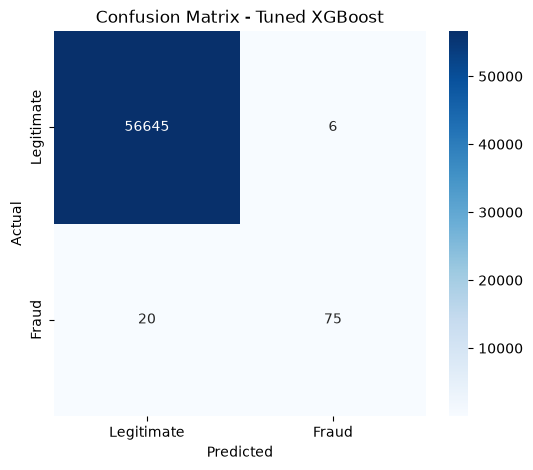

In [98]:
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Tuned XGBoost")
plt.show()

RandomizedSearchCV was used to optimize the XGBoost model using PR-AUC as the scoring metric. The best model achieved a cross-validation PR-AUC of 85.32%. On the test set, the tuned model achieved 92.59% precision, 78.95% recall, 85.23% F1-score, 97.86% ROC-AUC and 83.47% PR-AUC. Compared with the class-weighted XGBoost model, ROC-AUC and PR-AUC improved, indicating better overall ranking performance. However, recall remained unchanged at 78.95%, while precision and F1-score decreased slightly because false positives increased from 3 to 6. Therefore, further threshold optimization can be considered to identify a more suitable operating point for fraud detection.

### Threshold Optimization

In [99]:
from sklearn.model_selection import train_test_split

X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training subset:", X_train_sub.shape)
print("Validation set:", X_val.shape)

print("\nTraining subset class distribution:")
print(y_train_sub.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

Training subset: (181584, 30)
Validation set: (45396, 30)

Training subset class distribution:
Class
0    181282
1       302
Name: count, dtype: int64

Validation class distribution:
Class
0    45320
1       76
Name: count, dtype: int64


In [100]:
# Train the tuned XGBoost configuration on the training subset

xgb_threshold_model = XGBClassifier(
    n_estimators=202,
    max_depth=7,
    learning_rate=0.14907884894416698,
    min_child_weight=5,
    subsample=0.8337498258560773,
    colsample_bytree=0.8123620356542087,
    gamma=0.4753571532049581,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_threshold_model.fit(
    X_train_sub,
    y_train_sub
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8123620356542087
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [101]:
# Get validation probabilities

y_val_prob = xgb_threshold_model.predict_proba(X_val)[:, 1]

In [102]:
# Test different thresholds

threshold_results = []

for threshold in np.arange(0.10, 0.91, 0.05):
    
    y_val_pred = (y_val_prob >= threshold).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_val, y_val_pred, zero_division=0),
        "Recall": recall_score(y_val, y_val_pred, zero_division=0),
        "F1 Score": f1_score(y_val, y_val_pred, zero_division=0),
        "PR-AUC": average_precision_score(y_val, y_val_prob)
    })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df.round(4))

,Threshold,Precision,Recall,F1 Score,PR-AUC
0,0.10,0.8684,0.8684,0.8684,0.8776
1,0.15,0.9296,0.8684,0.8980,0.8776
2,0.20,0.9429,0.8684,0.9041,0.8776
3,0.25,0.9429,0.8684,0.9041,0.8776
4,0.30,0.9429,0.8684,0.9041,0.8776
5,0.35,0.9565,0.8684,0.9103,0.8776
6,0.40,0.9559,0.8553,0.9028,0.8776
7,0.45,0.9559,0.8553,0.9028,0.8776
8,0.50,0.9559,0.8553,0.9028,0.8776
9,0.55,0.9559,0.8553,0.9028,0.8776


In [103]:
# Find the threshold with the best F1

best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print("Best Threshold based on F1 Score:")
print(best_threshold_row)

Best Threshold based on F1 Score:
Threshold    0.350000
Precision    0.956522
Recall       0.868421
F1 Score     0.910345
PR-AUC       0.877614
Name: 5, dtype: float64


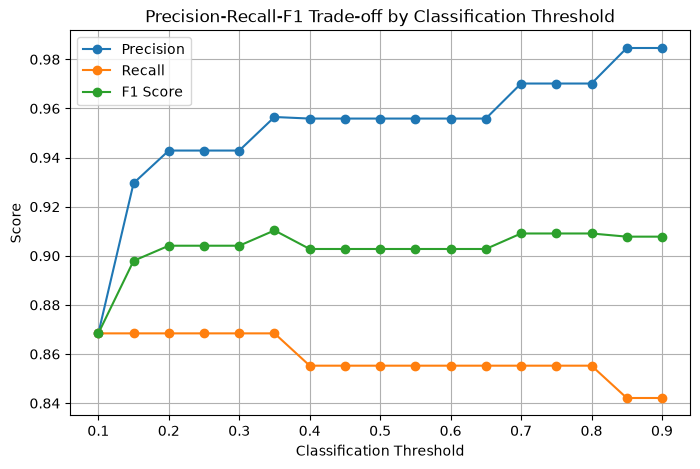

In [104]:
# Precision Recall trade-off

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall-F1 Trade-off by Classification Threshold")
plt.legend()
plt.grid(True)
plt.show()

In [105]:
# Train the final XGBoost Model

final_xgb = XGBClassifier(
    n_estimators=202,
    max_depth=7,
    learning_rate=0.14907884894416698,
    min_child_weight=5,
    subsample=0.8337498258560773,
    colsample_bytree=0.8123620356542087,
    gamma=0.4753571532049581,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

final_xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8123620356542087
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [106]:
# Test Probability

y_test_prob_final = final_xgb.predict_proba(X_test)[:, 1]

In [107]:
# Applying the selected threshold

optimal_threshold = 0.35

y_test_pred_final = (
    y_test_prob_final >= optimal_threshold
).astype(int)

In [108]:
# Final Evaluation

print("Final XGBoost - Threshold Optimized")

print("Threshold:", optimal_threshold)

print("Accuracy:", accuracy_score(y_test, y_test_pred_final))
print("Precision:", precision_score(y_test, y_test_pred_final))
print("Recall:", recall_score(y_test, y_test_pred_final))
print("F1 Score:", f1_score(y_test, y_test_pred_final))
print("ROC-AUC:", roc_auc_score(y_test, y_test_prob_final))
print("PR-AUC:", average_precision_score(y_test, y_test_prob_final))

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred_final))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_final))

Final XGBoost - Threshold Optimized
Threshold: 0.35
Accuracy: 0.9994889507630493
Precision: 0.8837209302325582
Recall: 0.8
F1 Score: 0.8397790055248618
ROC-AUC: 0.9785718466436697
PR-AUC: 0.8346893482825348

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.88      0.80      0.84        95

    accuracy                           1.00     56746
   macro avg       0.94      0.90      0.92     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56641    10]
 [   19    76]]


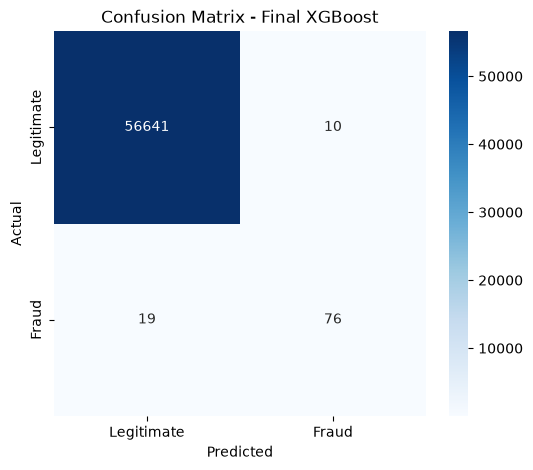

In [109]:
# Final Confusion matrix

cm_final = confusion_matrix(y_test, y_test_pred_final)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Final XGBoost")
plt.show()

The final XGBoost model was developed using class weighting to address severe class imbalance, followed by hyperparameter optimization using RandomizedSearchCV with PR-AUC as the optimization metric. A classification threshold of 0.35 was selected using a separate validation set to improve the precision-recall trade-off. The final model was then retrained using the complete training dataset and evaluated on the untouched test set. It achieved 99.95% accuracy, 88.37% precision, 80.00% recall, 83.98% F1-score, 97.86% ROC-AUC and 83.47% PR-AUC. The model correctly identified 76 of 95 fraudulent transactions, while missing 19 fraud cases and generating 10 false positives. The results demonstrate strong fraud-detection performance while highlighting the trade-off between maximizing fraud detection and minimizing false alerts.

### Final Model Evaluation Plots

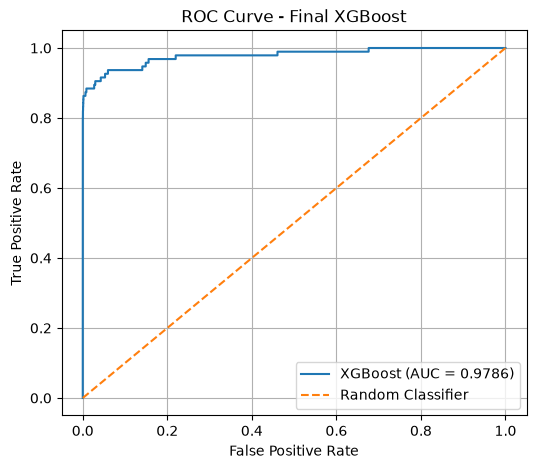

In [113]:
# ROC_Curve

fpr, tpr, thresholds_roc = roc_curve(
    y_test,
    y_test_prob_final
)

plt.figure(figsize=(6,5))

plt.plot(
    fpr,
    tpr,
    label=f"XGBoost (AUC = {roc_auc_score(y_test, y_test_prob_final):.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Final XGBoost")
plt.legend()
plt.grid(True)
plt.show()

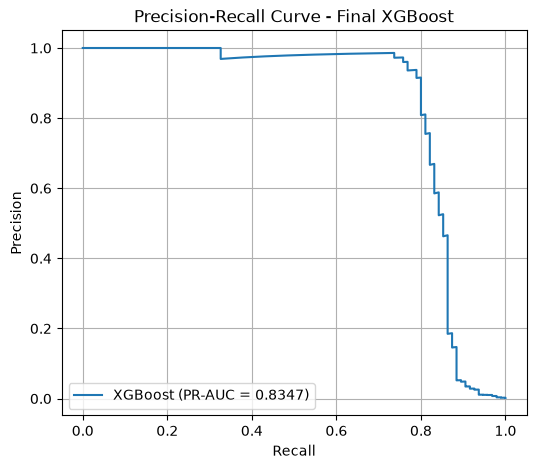

In [116]:
# Precision-Recall Curve

precision_curve, recall_curve, thresholds_pr = precision_recall_curve(
    y_test,
    y_test_prob_final
)

plt.figure(figsize=(6,5))

plt.plot(
    recall_curve,
    precision_curve,
    label=f"XGBoost (PR-AUC = {average_precision_score(y_test, y_test_prob_final):.4f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Final XGBoost")
plt.legend()
plt.grid(True)
plt.show()

The final XGBoost model achieved a PR-AUC of 83.47%, indicating strong performance in identifying fraudulent transactions while maintaining a relatively high precision across different classification thresholds.

In [117]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_xgb.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
14,V14,0.574109
4,V4,0.054544
12,V12,0.030610
10,V10,0.023756
19,V19,0.023690
8,V8,0.023547
3,V3,0.022438
20,V20,0.020486
13,V13,0.017004
9,V9,0.014959


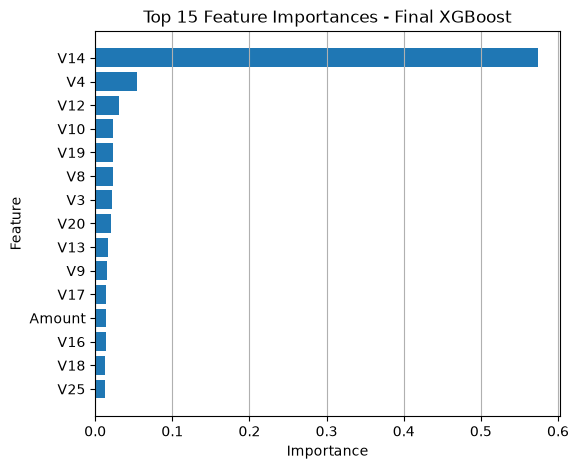

In [120]:
top_features = feature_importance.head(15)

plt.figure(figsize=(6,5))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Final XGBoost")
plt.grid(axis="x")
plt.show()

In [121]:
print("Top 10 Features:")
display(feature_importance.head(10))

Top 10 Features:


,Feature,Importance
14,V14,0.574109
4,V4,0.054544
12,V12,0.030610
10,V10,0.023756
19,V19,0.023690
8,V8,0.023547
3,V3,0.022438
20,V20,0.020486
13,V13,0.017004
9,V9,0.014959


Observation:

The final XGBoost model achieved a ROC-AUC of 97.86%, demonstrating strong ability to distinguish fraudulent transactions from legitimate transactions across different classification thresholds.

The final XGBoost model achieved a PR-AUC of 83.47%, indicating strong performance in identifying the minority fraud class while maintaining relatively high precision across different recall levels.

V14 was identified as the most influential feature according to the XGBoost feature-importance analysis. However, since the V1–V28 variables are anonymized PCA-transformed features, their direct business interpretation is not available.



In [123]:
# Save the final model files

# Save final XGBoost model
joblib.dump(
    final_xgb,
    "final_xgb_model.pkl"
)

# Save feature column order
feature_columns = X_train.columns.tolist()

joblib.dump(
    feature_columns,
    "feature_columns.pkl"
)

# Save optimized classification threshold
optimal_threshold = 0.35

joblib.dump(
    optimal_threshold,
    "threshold.pkl"
)

print("Model files saved successfully.")

Model files saved successfully.


In [124]:
# Verify the files

print("Final XGBoost Model:",
      os.path.exists("final_xgb_model.pkl"))

print("Feature Columns:",
      os.path.exists("feature_columns.pkl"))

print("Classification Threshold:",
      os.path.exists("threshold.pkl"))

Final XGBoost Model: True
Feature Columns: True
Classification Threshold: True


In [125]:
# Save feature importance

feature_importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("Feature importance saved successfully.")

Feature importance saved successfully.


In [126]:
# Verify that the model can actually be loaded

# Load the saved files
loaded_model = joblib.load("final_xgb_model.pkl")
loaded_features = joblib.load("feature_columns.pkl")
loaded_threshold = joblib.load("threshold.pkl")

print("Model loaded:", type(loaded_model).__name__)
print("Number of features:", len(loaded_features))
print("Threshold:", loaded_threshold)
print("Features:", loaded_features)

Model loaded: XGBClassifier
Number of features: 30
Threshold: 0.35
Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [127]:
# Test the saved model on one test transaction

# Take one transaction from the test set
sample_transaction = X_test.iloc[[0]]

# Probability of fraud
sample_probability = loaded_model.predict_proba(
    sample_transaction
)[:, 1][0]

# Apply our optimized threshold
sample_prediction = int(
    sample_probability >= loaded_threshold
)

print("Fraud Probability:", sample_probability)
print("Prediction:", sample_prediction)

if sample_prediction == 1:
    print("Result: Fraudulent Transaction")
else:
    print("Result: Legitimate Transaction")

Fraud Probability: 3.004579e-06
Prediction: 0
Result: Legitimate Transaction
